In [ ]:
import os
import json
import numpy as np

# ======================================================
#  缓存全局内容：避免每次都重新读 JSON
# ======================================================
_NX_PROP_CACHE = None

def _load_nx_properties():
    """
    从目录 /home/gaochi/leaf_matching/datasets/analysis/nx_properties
    加载所有 JSON 文件。

    JSON 文件格式与你给出的示例完全一致：
    {
      "('cora_ml', 0.1)": {
          "train": {...},
          "whole": {...}
      },
      "('cora_ml', 0.2)": {...},
      ...
    }
    """
    global _NX_PROP_CACHE
    if _NX_PROP_CACHE is not None:
        return _NX_PROP_CACHE


    all_data = {}

    fpath = "/home/gaochi/leaf_matching/datasets/analysis/nx_properties"
    try:
        with open(fpath, "r") as f:
            d = json.load(f)
        # 直接合并字典
        all_data.update(d)
    except Exception as e:
        print(f"[WARN] 无法读取 {fpath}: {e}")

    _NX_PROP_CACHE = all_data
    return _NX_PROP_CACHE


# ======================================================
#   主接口：get_reciprocity(dataset, ratio)
# ======================================================

def get_reciprocity(dataset, ratio):
    """
    输入:
        dataset: str, 如 'cora_ml'
        ratio:   float, 如 0.1

    输出:
        train['reciprocity'] 若存在，否则 np.nan
    """

    all_data = _load_nx_properties()

    # JSON 的键是字符串形式的 Python tuple: "('cora_ml', 0.1)"
    key = f"('{dataset}', {ratio})"

    if key not in all_data:
        # 一些 JSON 可能写成 "('cora_ml', 0.1)" vs "('cora_ml', 0.1)" 格式不一致，
        # 因此我们再尝试 floating 的格式化
        key2 = f"('{dataset}', {float(ratio)})"
        if key2 not in all_data:
            return np.nan
        entry = all_data[key2]
    else:
        entry = all_data[key]

    # 从 entry['train']['reciprocity'] 获取值
    try:
        rec = entry["train"]["assor"]
        return float(rec)
    except Exception:
        return np.nan


In [85]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# ============================================
# 你现有代码中的：目录、算法、数据集、同义字段
# ============================================
algo_dirs = {
    "ours-oi":   "/home/gaochi/leaf_matching/logs_oi/results",
    "ours-oiht": "/home/gaochi/leaf_matching/logs_ht_oi/results",
}

datasets = ['cora', 'citeseer',
            'icews18_max', 'twitter', 'ogbl_citation2',
            'yeast']

split_ticks = [0.1,0.9]

# ---- 同义词映射 ----
COLUMN_SYNONYMS = {
    'ap': ['ap','AP','pr_auc','pr','PR','pr-auc','average_precision','avg_precision'],
}
SPLIT_COL_CANDIDATES = ['split_ratio','split','ratio']

# ---- 解析 mean±std 的正则 ----
import re
_float_re = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')

def parse_mean_std(x):
    if pd.isna(x):
        return np.nan, 0.0
    if isinstance(x, (int,float,np.number)):
        return float(x),0.0
    s = str(x)
    nums = _float_re.findall(s)
    if not nums:
        return np.nan,0.0
    mean = float(nums[0])
    std  = float(nums[1]) if len(nums)>=2 else 0.0
    return mean,std

def select_column(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def extract_metric_series(df, metric_key):
    col = select_column(df, COLUMN_SYNONYMS[metric_key])
    if col is None:
        raise KeyError(f"没有找到 {metric_key} 列：{df.columns}")
    means = []
    for v in df[col].tolist():
        m,_ = parse_mean_std(v)
        means.append(m)
    means = np.array(means,dtype=float)
    return means

def extract_split_ratio(df):
    col = select_column(df, SPLIT_COL_CANDIDATES)
    if col is None:
        raise KeyError(f"没有 split_ratio 列：{df.columns}")
    return pd.to_numeric(df[col],errors='coerce').to_numpy()



# ============================================
#        主流程：计算 Δ、做拟合、输出结果
# ============================================
print("ratio | pearson_r | slope | trend")
print("---------------------------------------")

for ratio in split_ticks:
    X = []   # reciprocity(d,ratio)
    Y = []   # Δ(d,ratio)

    for d in datasets:

        # --------------------
        # 读取 ours-oi
        # --------------------
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{d}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr = extract_split_ratio(df_oi)
        ap_oi = extract_metric_series(df_oi,'ap')

        # 找到对应 ratio 的行
        idx = np.where(np.isclose(sr, ratio))[0]
        if len(idx)==0:
            continue
        ap_oi_val = ap_oi[idx[0]]

        # --------------------
        # 读取 ours-oiht
        # --------------------
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{d}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr2 = extract_split_ratio(df_ht)
        ap_ht = extract_metric_series(df_ht,'ap')

        idx2 = np.where(np.isclose(sr2, ratio))[0]
        if len(idx2)==0:
            print(f"[WARN] 在 ours-oiht 中找不到 {d} ratio={ratio} 的数据")
            continue
        ap_ht_val = ap_ht[idx2[0]]

        # --------------------
        # 差值 Δ
        # --------------------
        delta = ap_ht_val - ap_oi_val

        # reciprocity
        rec = get_reciprocity(d, 0.9)
        print(f"[DEBUG] d={d}, ratio={ratio:.1f}, rec={rec}, Δ={delta}")

        if np.isnan(rec):
            continue

        X.append(rec)
        Y.append(delta)

    # 至少要有两个 dataset 才能算趋势
    if len(X) < 2:
        print(f"{ratio:.1f} | insufficient data")
        continue

    X_arr = np.array(X).reshape(-1,1)
    Y_arr = np.array(Y)

    # 皮尔逊相关系数
    pearson_r,_ = pearsonr(X_arr.ravel(), Y_arr)

    # 线性拟合 Δ = a*rec + b
    reg = LinearRegression().fit(X_arr, Y_arr)
    slope = float(reg.coef_[0])

    trend = "positive" if slope>0 else "negative" if slope<0 else "flat"

    print(f"{ratio:.1f} | {pearson_r:+.4f} | {slope:+.4f} | {trend}")


ratio | pearson_r | slope | trend
---------------------------------------
[DEBUG] d=cora, ratio=0.1, rec=0.05250085062946581, Δ=-2.306600000000003
[DEBUG] d=citeseer, ratio=0.1, rec=0.007465781833264205, Δ=-0.31620000000000203
[DEBUG] d=icews18_max, ratio=0.1, rec=0.46448762189546194, Δ=-2.2357000000000014
[DEBUG] d=twitter, ratio=0.1, rec=0.43368519745069234, Δ=-4.107600000000005
[DEBUG] d=ogbl_citation2, ratio=0.1, rec=0.002296154780422382, Δ=-1.8983999999999952
[DEBUG] d=yeast, ratio=0.1, rec=0.0020304568527918783, Δ=4.096800000000002
0.1 | -0.5832 | -7.3485 | negative
[DEBUG] d=cora, ratio=0.9, rec=0.05250085062946581, Δ=1.8769999999999953
[DEBUG] d=citeseer, ratio=0.9, rec=0.007465781833264205, Δ=5.969800000000006
[DEBUG] d=icews18_max, ratio=0.9, rec=0.46448762189546194, Δ=-0.38860000000001094
[DEBUG] d=twitter, ratio=0.9, rec=0.43368519745069234, Δ=1.9506000000000085
[DEBUG] d=ogbl_citation2, ratio=0.9, rec=0.002296154780422382, Δ=-0.38240000000000407
[DEBUG] d=yeast, ratio=0.9,

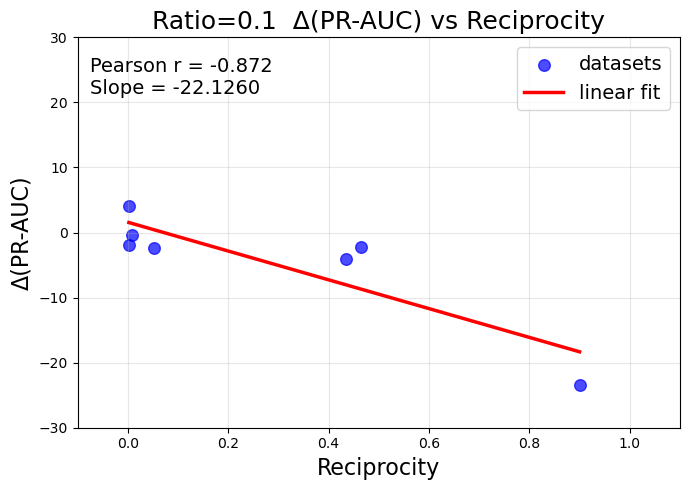

[INFO] 已保存图: ratio_0.1_delta_vs_reciprocity.pdf


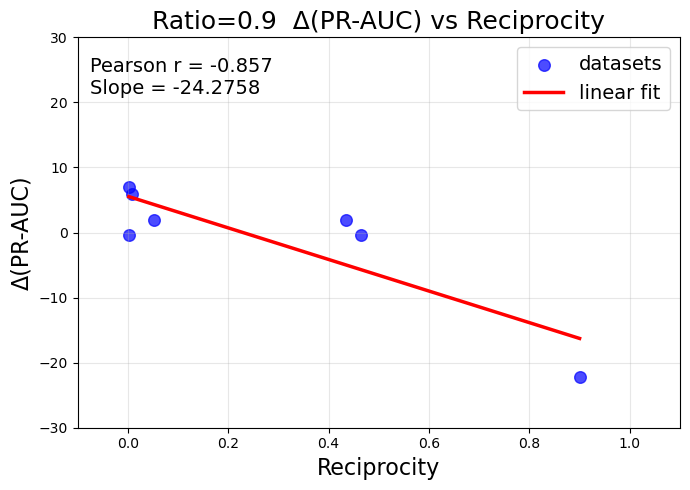

[INFO] 已保存图: ratio_0.9_delta_vs_reciprocity.pdf


In [70]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ==========================================================
#  前置依赖：
#  你已有：
#    - datasets
#    - split_ticks
#    - extract_metric_series
#    - extract_split_ratio
#    - get_reciprocity
#    - algo_dirs["ours-oi"], algo_dirs["ours-oiht"]
# ==========================================================

def compute_delta_for_ratio(ratio):
    """
    返回该 ratio 下：
    X = reciprocity(d, 0.9)
    Y = Δ = AP_oiht - AP_oi
    """
    X = []
    Y = []

    for d in datasets:
        # ours-oi
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{d}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr_oi = extract_split_ratio(df_oi)
        ap_oi = extract_metric_series(df_oi, 'ap')
        idx = np.where(np.isclose(sr_oi, ratio))[0]
        if len(idx)==0:
            continue
        ap_oi_val = ap_oi[idx[0]]

        # ours-oiht
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{d}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr_ht = extract_split_ratio(df_ht)
        ap_ht = extract_metric_series(df_ht, 'ap')
        idx2 = np.where(np.isclose(sr_ht, ratio))[0]
        if len(idx2)==0:
            continue
        ap_ht_val = ap_ht[idx2[0]]

        # 差值 Δ
        delta = ap_ht_val - ap_oi_val

        # reciprocity
        rec = get_reciprocity(d, 0.9)
        if np.isnan(rec):
            continue

        X.append(rec)
        Y.append(delta)

    return np.array(X), np.array(Y)


# ==========================================================
#             为每个 ratio 绘制一张图
# ==========================================================

for ratio in split_ticks:

    X, Y = compute_delta_for_ratio(ratio)
    if len(X) < 2:
        print(f"[WARN] ratio={ratio} 数据不足，跳过")
        continue

    # 拟合
    X_fit = X.reshape(-1,1)
    model = LinearRegression().fit(X_fit, Y)
    slope  = float(model.coef_[0])
    inter  = float(model.intercept_)
    pearson_r, _ = pearsonr(X, Y)

    # 绘制
    plt.figure(figsize=(7,5))
    plt.scatter(X, Y, s=70, color='blue', alpha=0.7, label='datasets')

    # 拟合线
    x_line = np.linspace(min(X), max(X), 200)
    y_line = slope * x_line + inter
    plt.plot(x_line, y_line, color='red', linewidth=2.5, label='linear fit')

    # 标注
    plt.title(f"Ratio={ratio}  Δ(PR-AUC) vs Reciprocity", fontsize=18)
    plt.xlabel("Reciprocity", fontsize=16)
    plt.ylabel("Δ(PR-AUC)", fontsize=16)

    plt.text(
        0.02, 0.95,
        f"Pearson r = {pearson_r:+.3f}\nSlope = {slope:+.4f}",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.xlim(-0.1,1.1)
    plt.ylim(-30, 30)

    out_path = f"ratio_{ratio}_delta_vs_reciprocity.pdf"
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()

    print(f"[INFO] 已保存图: {out_path}")


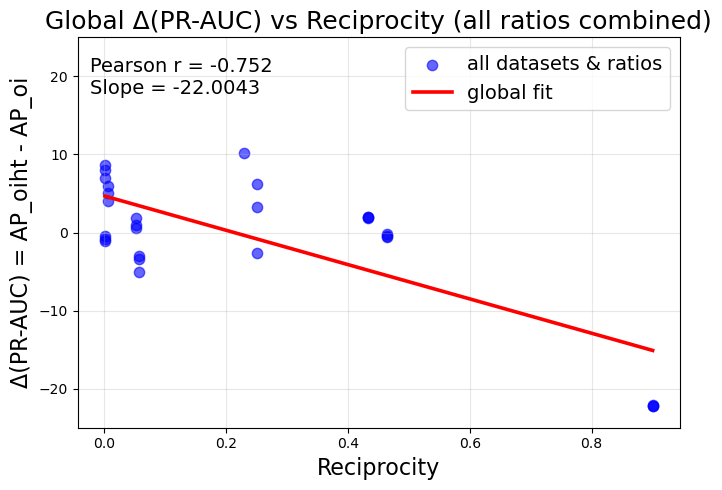

[INFO] 全局拟合图已保存：global_delta_vs_reciprocity.pdf
[INFO] Pearson r = -0.7522, Slope = -22.004251


In [49]:
# ==========================================================
#      全部 ratio 合并 — 全局散点图 + 全局线性拟合
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ----------- 累积所有 ratio 的点 ---------------
X_all = []
Y_all = []

for ratio in [0.7,0.8,0.9]:
    X, Y = compute_delta_for_ratio(ratio)
    if len(X) == 0:
        continue
    X_all.append(X)
    Y_all.append(Y)

if len(X_all)==0:
    print("[ERROR] 无任何数据可用于全局拟合")
else:
    X_all = np.concatenate(X_all)
    Y_all = np.concatenate(Y_all)

    # ------------------------------
    # 全局拟合
    # ------------------------------
    X_fit = X_all.reshape(-1,1)
    model = LinearRegression().fit(X_fit, Y_all)
    slope  = float(model.coef_[0])
    inter  = float(model.intercept_)
    pearson_r,_ = pearsonr(X_all, Y_all)

    # ------------------------------
    # 绘图
    # ------------------------------
    plt.figure(figsize=(7,5))
    plt.scatter(X_all, Y_all, s=55, color='blue', alpha=0.6, label="all datasets & ratios")

    # 拟合直线
    x_line = np.linspace(min(X_all), max(X_all), 300)
    y_line = slope * x_line + inter
    plt.plot(x_line, y_line, color='red', linewidth=2.6, label="global fit")

    # 注释
    plt.title("Global Δ(PR-AUC) vs Reciprocity (all ratios combined)", fontsize=18)
    plt.xlabel("Reciprocity", fontsize=16)
    plt.ylabel("Δ(PR-AUC) = AP_oiht - AP_oi", fontsize=16)

    plt.text(
        0.02, 0.95,
        f"Pearson r = {pearson_r:+.3f}\nSlope = {slope:+.4f}",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.ylim(-25, 25)
    # plt.xscale('log')

    out_path = "global_delta_vs_reciprocity.pdf"
    plt.tight_layout()
    plt.show()
    print(f"[INFO] 全局拟合图已保存：{out_path}")
    print(f"[INFO] Pearson r = {pearson_r:+.4f}, Slope = {slope:+.6f}")


/tmp/ipykernel_898395/3430118958.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(datasets))  # 多色


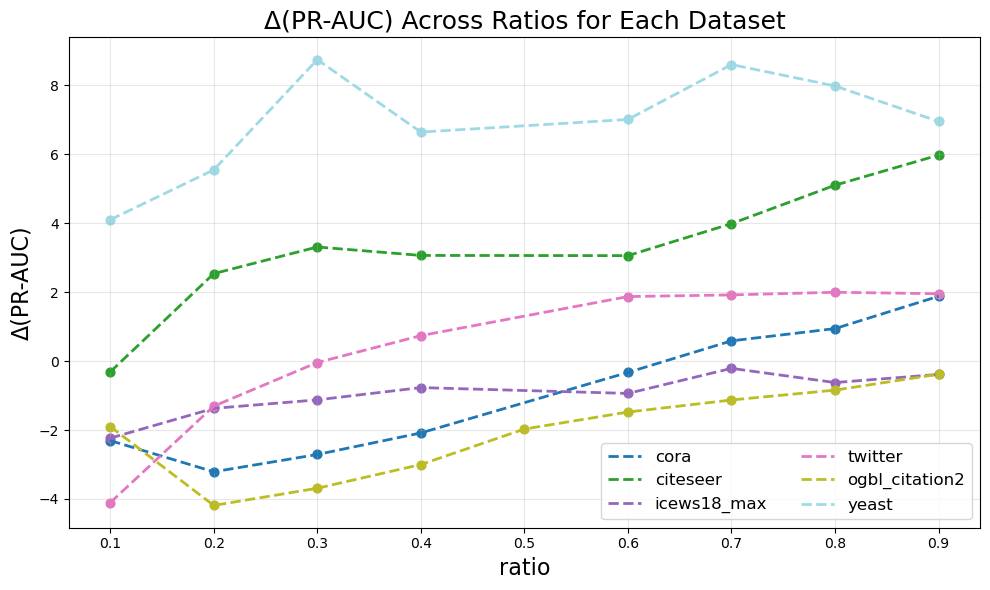

In [86]:
# ==========================================================
#     绘制：横轴 ratio，纵轴 Δ(PR-AUC)，每条曲线一个 dataset
# ==========================================================
from re import split
import matplotlib.pyplot as plt
import numpy as np

split_ticks = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

def compute_delta_series_for_dataset(dataset):
    """
    对单个 dataset，遍历所有 ratio，返回：
        ratios_used：实际有数据的 ratio 列表
        deltas：对应的 Δ
    """
    ratios_used = []
    deltas = []

    for ratio in split_ticks:
        X, Y = compute_delta_for_ratio(ratio)  # 该 ratio 所有数据集的点

        # compute_delta_for_ratio 返回的 X,Y 是“所有 dataset 的”
        # 但我们只需要 dataset = d 的值，因此单独提取一次：

        # ---- ours-oi ----
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{dataset}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr_oi = extract_split_ratio(df_oi)
        ap_oi = extract_metric_series(df_oi, 'ap')
        idx_oi = np.where(np.isclose(sr_oi, ratio))[0]
        if len(idx_oi) == 0:
            continue
        ap_oi_val = ap_oi[idx_oi[0]]

        # ---- ours-oiht ----
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{dataset}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr_ht = extract_split_ratio(df_ht)
        ap_ht = extract_metric_series(df_ht, 'ap')
        idx_ht = np.where(np.isclose(sr_ht, ratio))[0]
        if len(idx_ht) == 0:
            continue
        ap_ht_val = ap_ht[idx_ht[0]]

        delta = ap_ht_val - ap_oi_val

        ratios_used.append(ratio)
        deltas.append(delta)

    return np.array(ratios_used), np.array(deltas)


# ----------------------------------------------------------
#              绘制所有 dataset 的 ratio-delta 曲线
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

cmap = plt.cm.get_cmap("tab20", len(datasets))  # 多色

for i, d in enumerate(datasets):
    rts, dlt = compute_delta_series_for_dataset(d)

    if len(rts) == 0:
        continue

    plt.plot(
        rts, dlt,
        linestyle="--",
        linewidth=2,
        color=cmap(i),
        label=d
    )
    plt.scatter(rts, dlt, color=cmap(i), s=40)  # 标点

plt.xlabel("ratio", fontsize=16)
plt.ylabel("Δ(PR-AUC)", fontsize=16)
plt.title("Δ(PR-AUC) Across Ratios for Each Dataset", fontsize=18)

plt.xticks(split_ticks)
plt.grid(alpha=0.3)
plt.legend(fontsize=12, ncol=2)
plt.tight_layout()


out_path = "delta_vs_ratio_by_dataset.pdf"
plt.savefig(out_path)
plt.show() 
